# 03 — Улучшенные модели Prophet

## Цель ноутбука

Здесь последовательно сравниваем несколько вариантов Prophet и выбираем основную модель проекта. Все варианты используют ту же целевую логику, что и baseline: если доступен `load_rate`, модель обучается на нем, а качество оценивается в активных бронированиях.

## Какие варианты сравниваем

1. `baseline_additive` — базовая аддитивная сезонность.
2. `multiplicative` — мультипликативная сезонность.
3. `additive_monthly` — добавлена месячная сезонность.
4. `additive_school_holidays` — добавлен регрессор школьных каникул.
5. `additive_school_long_weekend` — добавлены школьные каникулы и длинные выходные.

## Критерий выбора

Основной критерий — MAPE на holdout, потому что для задачи недозаселения относительная ошибка важнее абсолютной. Ошибка в 50 бронирований при низкой загрузке опаснее, чем такая же ошибка в высокий сезон.

## Выходы

- `prophet_best.joblib`
- `forecast_best.parquet`
- `model_comparison.json`

## 1. Импорты и данные

In [1]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

if Path('artifacts_forecasting').exists():
    OUT_DIR = Path('artifacts_forecasting')
    FORECASTING_DIR = Path.cwd()
elif Path('forecasting/artifacts_forecasting').exists():
    OUT_DIR = Path('forecasting') / 'artifacts_forecasting'
    FORECASTING_DIR = Path.cwd() / 'forecasting'
else:
    raise FileNotFoundError('artifacts_forecasting was not found. Run from ml/ or ml/forecasting/.')

if str(FORECASTING_DIR) not in sys.path:
    sys.path.insert(0, str(FORECASTING_DIR))

from holidays_ru import build_holidays_df, get_school_holidays_flag

FORECAST_HORIZON = 365
HOLDOUT_DAYS = 90
CAPACITY_QUANTILE = 0.99

df_daily = pd.read_parquet(OUT_DIR / 'df_daily.parquet')
df_daily['ds'] = pd.to_datetime(df_daily['ds'])
df_daily = df_daily.sort_values('ds').reset_index(drop=True)
TARGET_COL = 'load_rate' if {'load_rate', 'capacity_est'}.issubset(df_daily.columns) else 'y'
holidays = build_holidays_df(include_official=True, include_school=True)

last_real_date = df_daily['ds'].max()
cutoff_date = last_real_date - pd.Timedelta(days=HOLDOUT_DAYS)
df_train = df_daily[df_daily['ds'] <= cutoff_date].copy()
df_test = df_daily[df_daily['ds'] > cutoff_date].copy()

print(f'Model target: {TARGET_COL}')
print(f'Train days: {len(df_train):,}; holdout days: {len(df_test):,}')


Model target: load_rate
Train days: 1,309; holdout days: 90


## 2. Вспомогательные функции

In [2]:
def mape_pct(y_true: pd.Series, y_pred: pd.Series) -> float:
    mask = y_true != 0
    return float(((y_true[mask] - y_pred[mask]).abs() / y_true[mask]).mean() * 100)

def capacity_for_dates(ds: pd.Series) -> pd.Series:
    if TARGET_COL != 'load_rate':
        return pd.Series(np.nan, index=ds.index)
    capacity_by_year = df_daily.groupby('year')['capacity_est'].first().to_dict()
    last_capacity = float(df_daily.sort_values('ds')['capacity_est'].iloc[-1])
    return ds.dt.year.map(capacity_by_year).fillna(last_capacity).astype(float)

def convert_forecast_to_bookings(forecast: pd.DataFrame) -> pd.DataFrame:
    result = forecast.copy()
    if TARGET_COL == 'load_rate':
        result['capacity_est'] = capacity_for_dates(result['ds'])
        result['yhat_rate'] = result['yhat']
        result['yhat_lower_rate'] = result['yhat_lower']
        result['yhat_upper_rate'] = result['yhat_upper']
        result['yhat'] = (result['yhat_rate'] * result['capacity_est']).clip(lower=0)
        result['yhat_lower'] = (result['yhat_lower_rate'] * result['capacity_est']).clip(lower=0)
        result['yhat_upper'] = (result['yhat_upper_rate'] * result['capacity_est']).clip(lower=0)
    return result

def add_regressors(frame: pd.DataFrame, names: list[str]) -> pd.DataFrame:
    result = frame.copy()
    if 'is_school_holidays' in names:
        result['is_school_holidays'] = get_school_holidays_flag(result['ds'])
    if 'is_long_weekend' in names:
        month = result['ds'].dt.month
        day = result['ds'].dt.day
        result['is_long_weekend'] = (
            ((month == 1) & (day <= 8)) |
            ((month == 5) & (day <= 10)) |
            ((month == 11) & (day >= 3) & (day <= 5))
        ).astype(int)
    return result

def build_model(config: dict) -> Prophet:
    model = Prophet(
        holidays=holidays,
        yearly_seasonality=config.get('yearly_seasonality', True),
        weekly_seasonality=config.get('weekly_seasonality', True),
        daily_seasonality=False,
        stan_backend='CMDSTANPY',
        seasonality_mode=config.get('seasonality_mode', 'additive'),
        interval_width=0.90,
        uncertainty_samples=500,
    )
    if config.get('monthly_seasonality'):
        model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
    for regressor in config.get('regressors', []):
        model.add_regressor(regressor)
    return model

def evaluate_variant(name: str, config: dict):
    regressors = config.get('regressors', [])
    train_features = add_regressors(df_train, regressors)
    test_features = add_regressors(df_test, regressors)
    train_prophet = train_features[['ds', TARGET_COL] + regressors].rename(columns={TARGET_COL: 'y'})

    model = build_model(config)
    model.fit(train_prophet)

    future = model.make_future_dataframe(periods=HOLDOUT_DAYS, freq='D', include_history=False)
    future = add_regressors(future, regressors)
    forecast = convert_forecast_to_bookings(model.predict(future))
    eval_df = test_features.merge(forecast[['ds', 'yhat'] + (['yhat_rate'] if TARGET_COL == 'load_rate' else [])], on='ds', how='inner')

    metrics = {
        'model': name,
        'mae': round(float(mean_absolute_error(eval_df['y'], eval_df['yhat'])), 2),
        'rmse': round(float(mean_squared_error(eval_df['y'], eval_df['yhat']) ** 0.5), 2),
        'mape_pct': round(mape_pct(eval_df['y'], eval_df['yhat']), 2),
    }
    if TARGET_COL == 'load_rate':
        metrics['mae_rate'] = round(float(mean_absolute_error(eval_df['load_rate'], eval_df['yhat_rate'])), 4)
        metrics['rmse_rate'] = round(float(mean_squared_error(eval_df['load_rate'], eval_df['yhat_rate']) ** 0.5), 4)
    return model, forecast, metrics


## 2.1. Гипотезы улучшения после EDA

В `01` видно, что главный сигнал ряда - годовая сезонность и изменение емкости. Поэтому все варианты продолжают работать с `load_rate`. Дальше проверяем только управляемые усложнения:

- `multiplicative`: проверяет, меняется ли амплитуда сезонности вместе с уровнем ряда;
- `additive_monthly`: добавляет месячную компоненту, потому что по EDA месяцы сильно различаются;
- `school_holidays` и `long_weekend`: проверяют календарные эффекты, но не предполагают, что они сильнее сезонности.


## 3. Сравнение вариантов Prophet

In [3]:
variants = {
    'baseline_additive': {
        'seasonality_mode': 'additive',
    },
    'multiplicative': {
        'seasonality_mode': 'multiplicative',
    },
    'additive_monthly': {
        'seasonality_mode': 'additive',
        'monthly_seasonality': True,
    },
    'additive_school_holidays': {
        'seasonality_mode': 'additive',
        'regressors': ['is_school_holidays'],
    },
    'additive_school_long_weekend': {
        'seasonality_mode': 'additive',
        'regressors': ['is_school_holidays', 'is_long_weekend'],
    },
}

models = {}
holdout_forecasts = {}
metrics_rows = []

for name, config in variants.items():
    print(f'Fitting {name}...')
    model, forecast, metrics = evaluate_variant(name, config)
    models[name] = model
    holdout_forecasts[name] = forecast
    metrics_rows.append(metrics)

df_comparison = pd.DataFrame(metrics_rows).sort_values('mape_pct').reset_index(drop=True)
display(df_comparison)


Fitting baseline_additive...


20:07:03 - cmdstanpy - INFO - Chain [1] start processing
20:07:03 - cmdstanpy - INFO - Chain [1] done processing
20:07:04 - cmdstanpy - INFO - Chain [1] start processing


Fitting multiplicative...


20:07:04 - cmdstanpy - INFO - Chain [1] done processing
20:07:04 - cmdstanpy - INFO - Chain [1] start processing


Fitting additive_monthly...


...

17:46:38 - cmdstanpy - INFO - Chain [1] done processing


Fitting additive_school_long_weekend...


17:46:39 - cmdstanpy - INFO - Chain [1] start processing


17:46:40 - cmdstanpy - INFO - Chain [1] done processing


,model,mae,rmse,mape_pct,mae_rate,rmse_rate
0,additive_monthly,118.45,151.68,19.36,0.1521,0.1947
1,additive_school_holidays,120.05,151.92,19.67,0.1541,0.1950
2,baseline_additive,120.10,151.96,19.68,0.1542,0.1951
3,multiplicative,121.77,151.53,19.72,0.1563,0.1945
4,additive_school_long_weekend,120.91,152.63,19.82,0.1552,0.1959


## 4. Визуальное сравнение

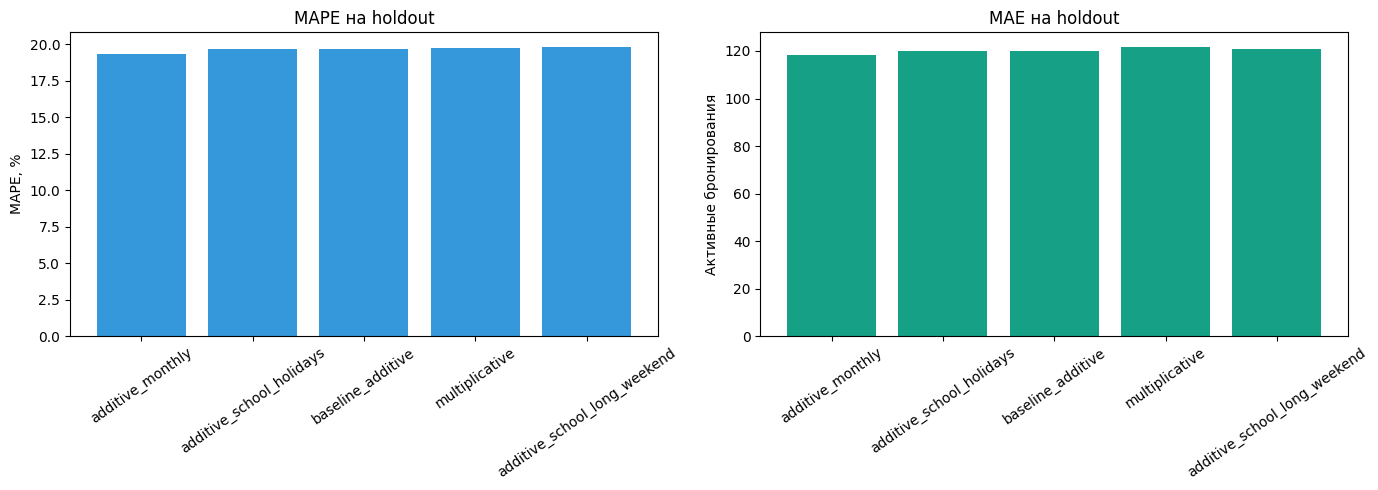

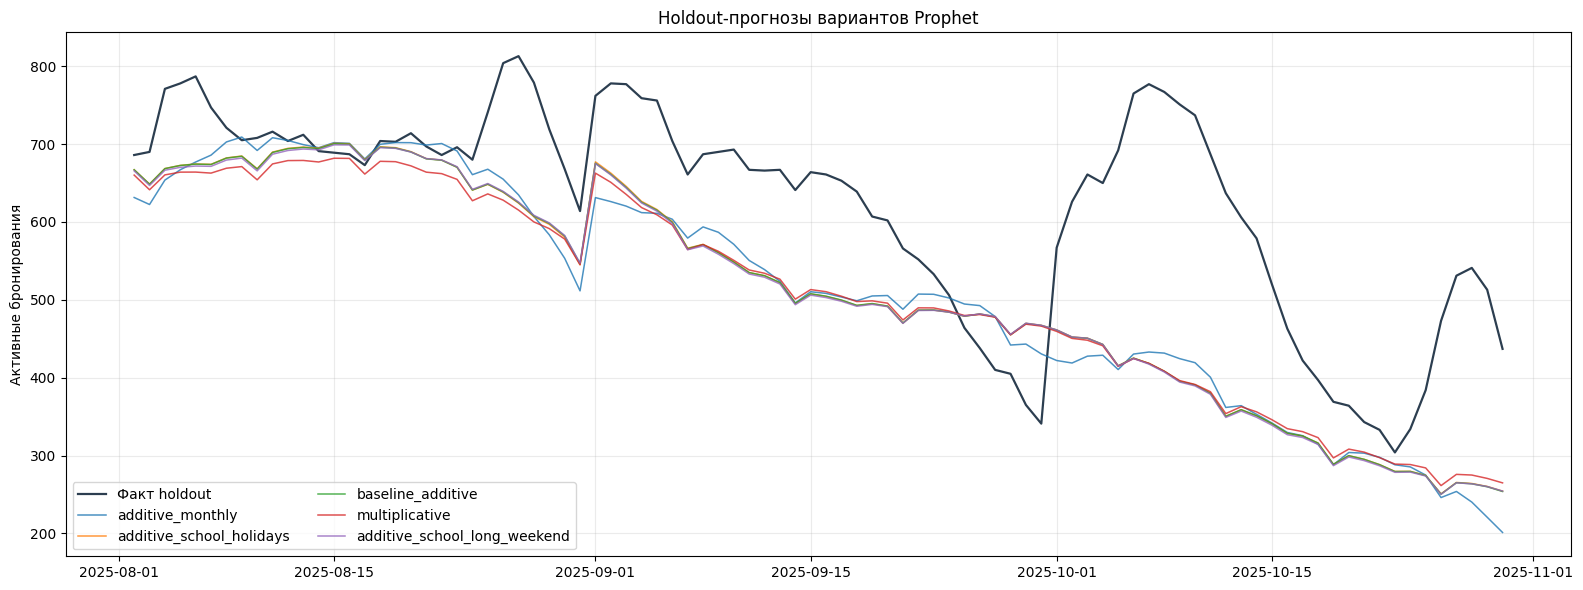

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(df_comparison['model'], df_comparison['mape_pct'], color='#3498db')
axes[0].set_title('MAPE на holdout')
axes[0].set_ylabel('MAPE, %')
axes[0].tick_params(axis='x', rotation=35)

axes[1].bar(df_comparison['model'], df_comparison['mae'], color='#16a085')
axes[1].set_title('MAE на holdout')
axes[1].set_ylabel('Активные бронирования')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(OUT_DIR / 'prophet_improved_model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_test['ds'], df_test['y'], color='#2c3e50', linewidth=1.6, label='Факт holdout')
for name in df_comparison['model']:
    forecast = holdout_forecasts[name]
    ax.plot(forecast['ds'], forecast['yhat'], linewidth=1.1, alpha=0.8, label=name)
ax.set_title('Holdout-прогнозы вариантов Prophet')
ax.set_ylabel('Активные бронирования')
ax.grid(True, alpha=0.25)
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig(OUT_DIR / 'prophet_improved_holdout_variants.png', dpi=160, bbox_inches='tight')
plt.show()


## 5. Обучение финальной модели и сохранение артефактов

20:07:07 - cmdstanpy - INFO - Chain [1] start processing
20:07:07 - cmdstanpy - INFO - Chain [1] done processing


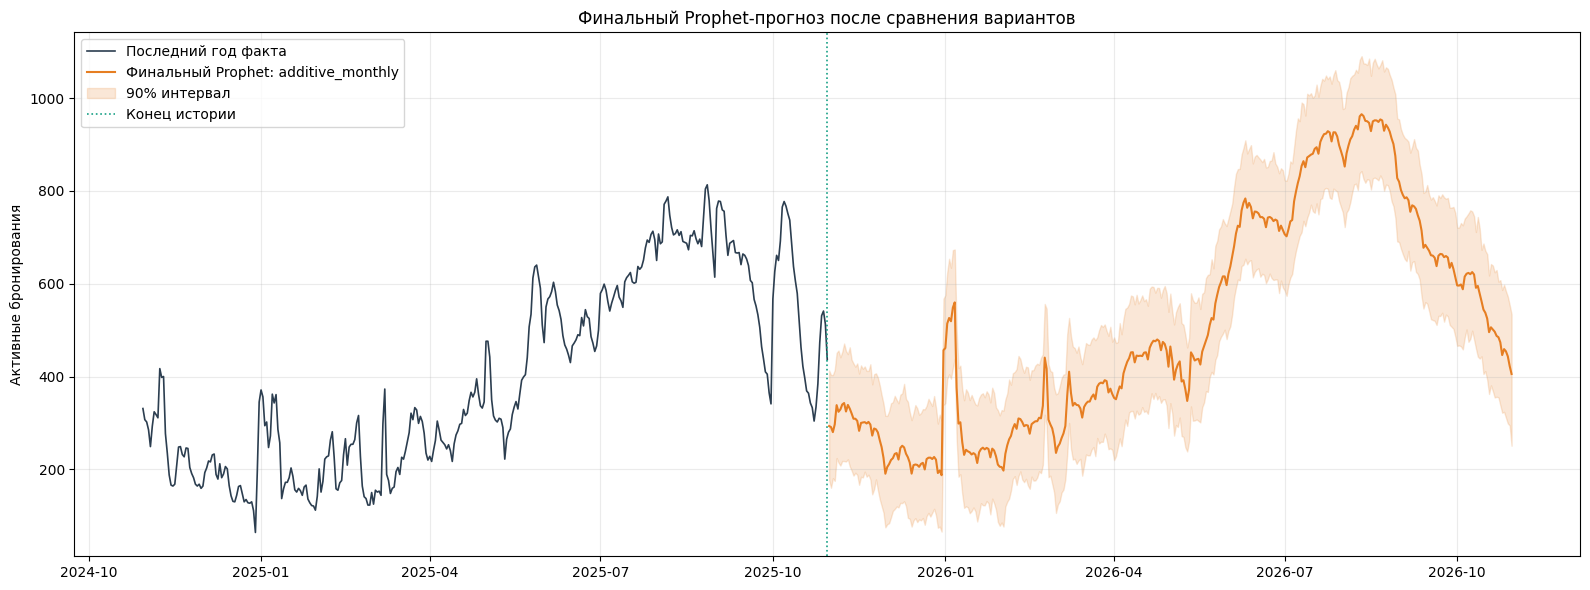

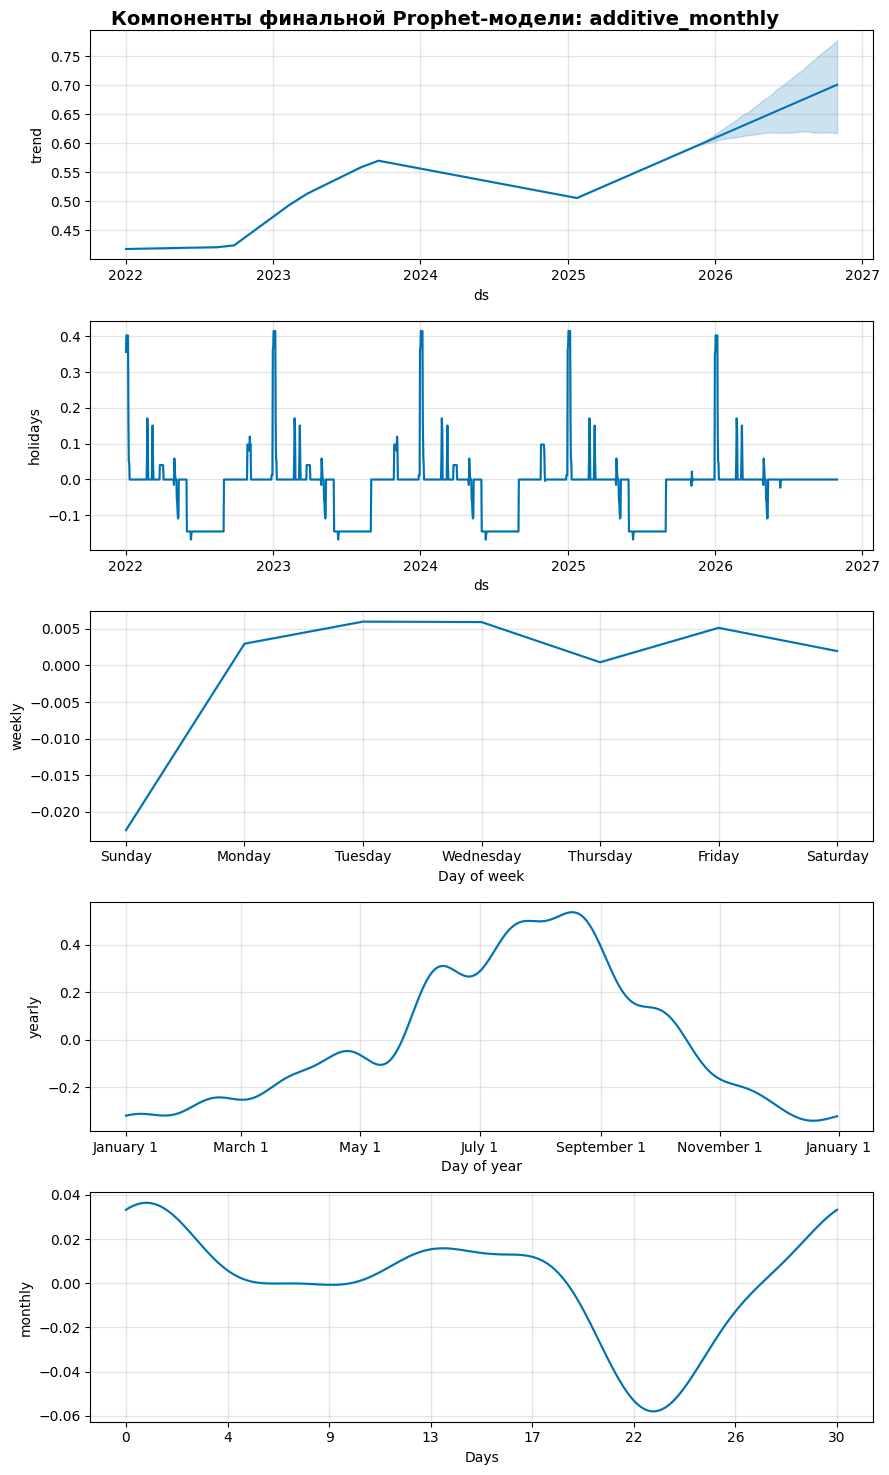

Selected model: additive_monthly
Saved: artifacts_forecasting\prophet_best.joblib
Saved: artifacts_forecasting\forecast_best.parquet
Saved: artifacts_forecasting\model_comparison.json


Selected model: additive_monthly
Saved: artifacts_forecasting\prophet_best.joblib
Saved: artifacts_forecasting\forecast_best.parquet
Saved: artifacts_forecasting\model_comparison.json


In [5]:
best_model_name = df_comparison.iloc[0]['model']
best_config = variants[best_model_name]
best_regressors = best_config.get('regressors', [])

final_train = add_regressors(df_daily, best_regressors)
final_prophet = final_train[['ds', TARGET_COL] + best_regressors].rename(columns={TARGET_COL: 'y'})

best_model = build_model(best_config)
best_model.fit(final_prophet)

future_final = best_model.make_future_dataframe(periods=FORECAST_HORIZON, freq='D', include_history=True)
future_final = add_regressors(future_final, best_regressors)
forecast_best_raw = best_model.predict(future_final)
forecast_best = convert_forecast_to_bookings(forecast_best_raw)

joblib.dump(best_model, OUT_DIR / 'prophet_best.joblib')
forecast_best.to_parquet(OUT_DIR / 'forecast_best.parquet', index=False)

comparison = {
    row['model']: {k: row[k] for k in row.index if k != 'model' and pd.notna(row[k])}
    for _, row in df_comparison.iterrows()
}
comparison['selected_model'] = best_model_name
comparison['target'] = TARGET_COL
comparison['capacity_quantile'] = CAPACITY_QUANTILE if TARGET_COL == 'load_rate' else None
with open(OUT_DIR / 'model_comparison.json', 'w', encoding='utf-8') as f:
    json.dump(comparison, f, ensure_ascii=False, indent=2)

fig, ax = plt.subplots(figsize=(16, 6))
history_tail = df_daily[df_daily['ds'] >= df_daily['ds'].max() - pd.Timedelta(days=365)]
future_part = forecast_best[forecast_best['ds'] > df_daily['ds'].max()]
ax.plot(history_tail['ds'], history_tail['y'], color='#2c3e50', linewidth=1.2, label='Последний год факта')
ax.plot(future_part['ds'], future_part['yhat'], color='#e67e22', linewidth=1.5, label=f'Финальный Prophet: {best_model_name}')
ax.fill_between(future_part['ds'], future_part['yhat_lower'], future_part['yhat_upper'], color='#e67e22', alpha=0.18, label='90% интервал')
ax.axvline(df_daily['ds'].max(), color='#16a085', linestyle=':', linewidth=1.2, label='Конец истории')
ax.set_title('Финальный Prophet-прогноз после сравнения вариантов')
ax.set_ylabel('Активные бронирования')
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'prophet_best_forecast.png', dpi=160, bbox_inches='tight')
plt.show()

components_fig = best_model.plot_components(forecast_best_raw)
components_fig.suptitle(f'Компоненты финальной Prophet-модели: {best_model_name}', fontsize=14, fontweight='bold')
components_fig.tight_layout()
components_fig.savefig(OUT_DIR / 'prophet_best_components.png', dpi=160, bbox_inches='tight')
plt.show()

print(f'Selected model: {best_model_name}')
print(f'Saved: {OUT_DIR / "prophet_best.joblib"}')
print(f'Saved: {OUT_DIR / "forecast_best.parquet"}')
print(f'Saved: {OUT_DIR / "model_comparison.json"}')
